In [2]:
import numpy as np
import pandas as pd
import pickle
import deepchem as dc
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
from rdkit import Chem
from rdkit.Chem import AllChem
from rdkit.Chem import rdMolDescriptors 
from rdkit.Chem import Draw
from rdkit.Chem import Descriptors
from rdkit import DataStructs
import selfies as sf
from statistics import mean
from statistics import stdev
import tensorflow as tf
from tensorflow.python.eager import polymorphic_function
polymorphic_function.reduce_retracing = True

# Check versions of DeepChem and RDKit
dc_version = dc.__version__
rk_version = Chem.rdBase.rdkitVersion
print(f"DeepChem version: {dc_version}, RDKit version: {rk_version}")

# Suppress DeepChem warnings regarding missing dependencies
import warnings
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-geometric dependency")
warnings.filterwarnings("ignore", message="Skipped loading modules with pytorch-lightning dependency")
warnings.filterwarnings("ignore", message="Skipped loading some Jax models")

DeepChem version: 2.8.0, RDKit version: 2022.09.5


In [3]:
ms = pd.read_pickle(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\_aromatic_2025_6022_CFHNO.pkl")
ms

,Name,Form,Mw,Cas,mz1,mz2,mz3,mz4,mz5,mz6,...,mz594,mz595,mz596,mz597,mz598,mz599,mz600,Filter_Form,SMILES,AtomGroup
185,"2,3-Dihydroxypropyl 5-fluoroorotate",C8H9FN2O6,248,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,OCC(O)COC(=O)C1=C(F)C(=O)NC(=O)N1,CFHNO
330,"Imidazolidine, 4-acetylamino-1-benzyl-2,5-diox...",C13H12F3N3O3,315,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)NC1(NC(=O)N(Cc2ccccc2)C1=O)C(F)(F)F,CFHNO
400,"Butanoic acid, carbonitrile, 2-(4-fluorophenyl...",C10H8FN3O,205,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(=O)/C(=N/Nc1ccc(F)cc1)C#N,CFHNO
439,"Pentanenitrile, 2-(4-fluorophenylhydrazono)-4-...",C12H12FN3O,233,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CC(C)C(=O)C(=NNc1ccc(F)cc1)C#N,CFHNO
485,"2,5-Difluoro-1-(triacetylribofuranosyl)imidazo...",C17H20F2N2O9,434,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)c1nc(F)n(c1F)C2(O[C@H](CO)[C@@H](O)[C@...,CFHNO
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
181736,"5H-Pyrrolo[1,2-a]quinoxalin-4-one, 7-trifluoro...",C12H11F3N2O,256,NaN,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,FC(F)(F)c1ccc2N3CCCC3C(=O)Nc2c1,CFHNO
181855,2-(4-Fluorophenyl)-5-morpholin-4-yl-3H-imidazo...,C15H16FN3O3,305,209392-07-4,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,COC(=O)c1[nH]c(nc1N2CCOCC2)c3ccc(F)cc3,CFHNO
181942,4-(4-Fluorophenyl)-3-morpholin-4-yl-1H-pyrrol-...,C17H19FN2O3,318,151054-91-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)c1[nH]cc(c2ccc(F)cc2)c1N3CCOCC3,CFHNO
182288,Ethyl m-trifluoromethylcarbanilate,C10H10F3NO2,233,2354-93-0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,True,CCOC(=O)Nc1cccc(c1)C(F)(F)F,CFHNO


In [ ]:
import deepchem as dc
import selfies as sf
import pandas as pd

X = ms.iloc[:, 4:604]     # spectra
y = ms.iloc[:, 605]       # smiles

se = []
dr = []  # list of indices to drop
c = 0

# Check all SMILES and filter out invalid/unsupported ones
for i in y:
    try:
        selfies_str = sf.encoder(i)
        se.append(selfies_str)
        if '.' in selfies_str:  # check for multi-molecule SMILES
            dr.append(c)
    except Exception as e:
        # Add to drop list if encoding fails (chemically invalid SMILES)
        dr.append(c)
    c += 1

# Drop problematic rows from original DataFrame
ms_cleaned = ms.drop(index=ms.index[dr]).reset_index(drop=True)

# Extract cleaned spectra and SMILES
X_clean = ms_cleaned.iloc[:, 4:604].to_numpy()
y_clean = ms_cleaned.iloc[:, 605].to_numpy()

# Create DeepChem dataset
ds = dc.data.DiskDataset.from_numpy(X_clean, y_clean)
ds

<DiskDataset X.shape: (np.int64(6022), np.int64(600)), y.shape: (np.int64(6022),), w.shape: (np.int64(6022),), task_names: [0]>

In [5]:
# Make a dictionary of all 'SELFIES' parts in the dataset

dataset = se
alphabet = sf.get_alphabet_from_selfies(dataset)
alphabet.add('[nop]')  # '[nop]' is a special padding symbol
alphabet = list(sorted(alphabet))
pad_to_len = max(sf.len_selfies(s) for s in dataset)
symbol_to_idx = {s: i for i, s in enumerate(alphabet)}
symbol_to_idx

{'[#Branch1]': 0,
 '[#Branch2]': 1,
 '[#C]': 2,
 '[#N]': 3,
 '[/-Ring1]': 4,
 '[/C]': 5,
 '[/N]': 6,
 '[/O]': 7,
 '[=Branch1]': 8,
 '[=Branch2]': 9,
 '[=CH0]': 10,
 '[=CH2]': 11,
 '[=C]': 12,
 '[=N+1]': 13,
 '[=N-1]': 14,
 '[=N]': 15,
 '[=O+1]': 16,
 '[=O]': 17,
 '[=Ring1]': 18,
 '[=Ring2]': 19,
 '[Branch1]': 20,
 '[Branch2]': 21,
 '[C-1]': 22,
 '[C@@H1]': 23,
 '[C@@]': 24,
 '[C@H1]': 25,
 '[C@]': 26,
 '[CH1]': 27,
 '[C]': 28,
 '[F]': 29,
 '[N+1]': 30,
 '[N-1]': 31,
 '[NH1]': 32,
 '[NH3+1]': 33,
 '[N]': 34,
 '[O-1]': 35,
 '[O]': 36,
 '[P]': 37,
 '[Ring1]': 38,
 '[Ring2]': 39,
 '[S]': 40,
 '[\\-Ring1]': 41,
 '[\\C]': 42,
 '[\\N]': 43,
 '[\\O]': 44,
 '[nop]': 45}

In [6]:
# Convert all SELFIES to ONE-HOT-FLAT (one-hot-flat can be used for machine learning)
sf_hot = sf.batch_selfies_to_flat_hot(se, vocab_stoi=symbol_to_idx, pad_to_len=pad_to_len)
# Create deepchem dataset X=spectrum y=SELFIES one-hot-flat
dataset = dc.data.NumpyDataset(X=np.array(ds.X, dtype='float'), y=sf_hot)

In [7]:
import deepchem as dc

seed = 123  
splitter = dc.splits.RandomStratifiedSplitter()

train_dataset, valid_dataset, test_dataset = splitter.train_valid_test_split(
    dataset=dataset,
    frac_train=0.9,
    frac_valid=0,
    frac_test=0.1,
    seed=seed
)

print(f"🔹 Seed used: {seed}")
print(f"📦 Training set size: {len(train_dataset)}")
print(f"📦 Validation set size: {len(valid_dataset)}")
print(f"📦 Test set size: {len(test_dataset)}")


🔹 Seed used: 123
📦 Training set size: 5343
📦 Validation set size: 0
📦 Test set size: 679


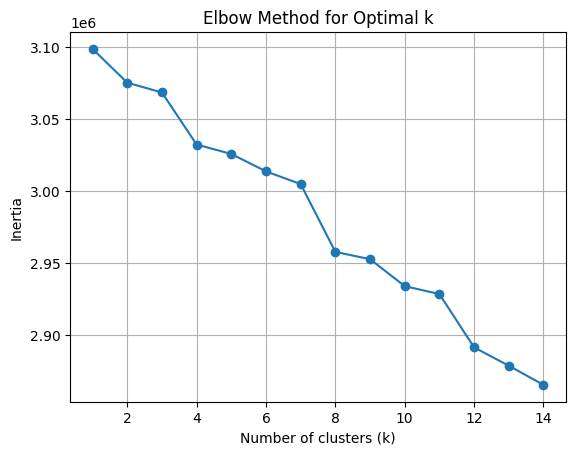

🔍 Elbow point detected at k = 4


In [8]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from kneed import KneeLocator 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(train_dataset.X)
inertias = []
k_range = range(1, 15)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto')
    kmeans.fit(X_train_scaled)
    inertias.append(kmeans.inertia_)
plt.plot(k_range, inertias, marker='o')
plt.xlabel('Number of clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.grid(True)
plt.show()
kl = KneeLocator(k_range, inertias, curve='convex', direction='decreasing')
print(f"🔍 Elbow point detected at k = {kl.elbow}")

In [ ]:
import os
import pickle
import numpy as np
from sklearn.cluster import KMeans

def train_and_save_kmeans_clusters(X_train, n_clusters=4,
                                   model_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with seed 123\kmeans_model",
                                   cluster_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset"):
    """
    Train KMeans on the training data, save the model, cluster data, and sample indices.

    Parameters:
    - X_train (np.ndarray): Training features
    - n_clusters (int): Number of clusters
    - model_dir (str): Path to save the KMeans model
    - cluster_dir (str): Path to save each cluster's data and indices

    Returns:
    - kmeans (KMeans): Trained model
    - cluster_files (dict): cluster_id -> file path for data and indices
    """
    os.makedirs(model_dir, exist_ok=True)
    os.makedirs(cluster_dir, exist_ok=True)

    # Train KMeans
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    labels = kmeans.fit_predict(X_train)

    # Save model
    model_path = os.path.join(model_dir, "kmeans_model.pkl")
    with open(model_path, "wb") as f:
        pickle.dump(kmeans, f)
    print(f"✅ KMeans model saved to: {model_path}")

    # Save each cluster's data and indices
    cluster_files = {}
    for cluster_id in range(n_clusters):
        indices = np.where(labels == cluster_id)[0]
        cluster_data = X_train[indices]

        data_path = os.path.join(cluster_dir, f"cluster_{cluster_id}.pkl")
        idx_path = os.path.join(cluster_dir, f"cluster_{cluster_id}_indices.npy")

        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)
        np.save(idx_path, indices)

        cluster_files[cluster_id] = {
            "data_path": data_path,
            "indices_path": idx_path
        }

        print(f"📁 Cluster {cluster_id} saved: {data_path}")
        print(f"📌 Indices saved: {idx_path}")

    return kmeans, cluster_files
kmeans_model, cluster_paths = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=4)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splittin

In [10]:
import pickle

cluster_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset"
clusters = {}

for i in range(4):
    path = f"{cluster_dir}/cluster_{i}.pkl"
    with open(path, "rb") as f:
        clusters[i] = pickle.load(f)

for i in clusters:
    print(f"Cluster {i} shape: {clusters[i].shape}")



Cluster 0 shape: (3659, 600)
Cluster 1 shape: (702, 600)
Cluster 2 shape: (875, 600)
Cluster 3 shape: (107, 600)


✅ KMeans model saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl
📁 Cluster 0 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy
📁 Cluster 1 saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl
📌 Indices saved: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splittin

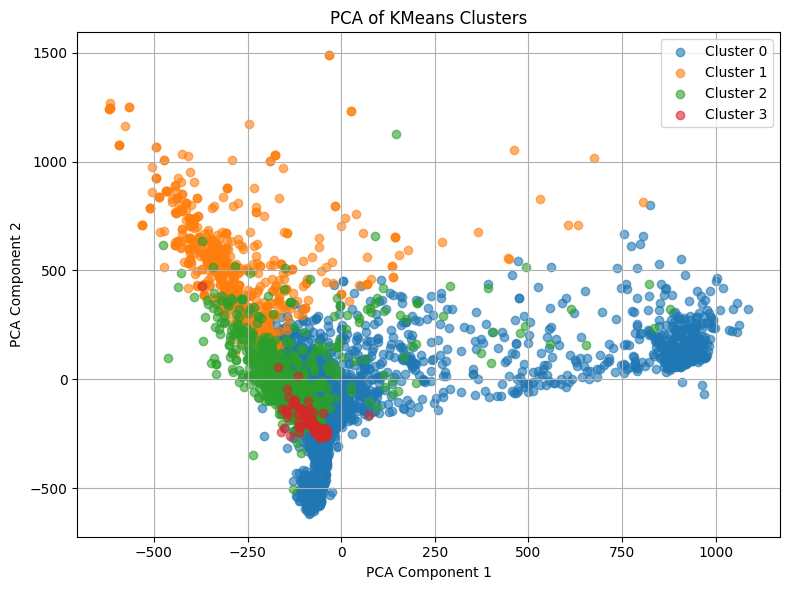

In [11]:

import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

def plot_clusters_pca(X, labels, title="PCA of KMeans Clusters"):
    """
    Plots clustered instances using PCA to reduce to 2D.

    Parameters:
    - X (np.ndarray): The input data (e.g., from train_dataset.X)
    - labels (np.ndarray): Cluster labels assigned by KMeans
    - title (str): Title for the plot
    """
    # Perform PCA
    pca = PCA(n_components=2)
    reduced = pca.fit_transform(X)

    # Plot clusters
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)
    for cluster_id in unique_labels:
        idx = labels == cluster_id
        plt.scatter(reduced[idx, 0], reduced[idx, 1], label=f"Cluster {cluster_id}", alpha=0.6)

    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()
kmeans_model, _ = train_and_save_kmeans_clusters(train_dataset.X, n_clusters=4)
labels = kmeans_model.predict(train_dataset.X)

# Plot clusters
plot_clusters_pca(train_dataset.X, labels)


In [12]:
import pickle
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with seed 123\kmeans_model\kmeans_model.pkl", "rb") as f:
    kmeans_model = pickle.load(f)

In [13]:


import os
import pickle
import numpy as np

def assign_and_save_clusters(X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test"):
    """
    Applies a trained KMeans model to a new dataset (e.g., test or validation),
    saves each cluster's data and sample indices.

    Parameters:
    - X (np.ndarray): Feature matrix (e.g., test_dataset.X)
    - kmeans_model (KMeans): Trained KMeans model
    - output_dir (str): Directory to save clustered data
    - dataset_label (str): Label for logging (e.g., "test" or "valid")
    """
    os.makedirs(output_dir, exist_ok=True)

    # Predict cluster labels
    cluster_labels = kmeans_model.predict(X)

    # For each cluster, save data and indices
    for cluster_id in np.unique(cluster_labels):
        indices = np.where(cluster_labels == cluster_id)[0]
        cluster_data = X[indices]

        # Save cluster data
        data_path = os.path.join(output_dir, f"cluster_{cluster_id}.pkl")
        with open(data_path, "wb") as f:
            pickle.dump(cluster_data, f)

        # Save indices
        idx_path = os.path.join(output_dir, f"cluster_{cluster_id}_indices.npy")
        np.save(idx_path, indices)

        print(f"✅ Saved {dataset_label} cluster {cluster_id} to: {data_path}")
        print(f"📌 Indices saved to: {idx_path}")

    return cluster_labels
test_X = test_dataset.X 
test_clusters = assign_and_save_clusters(test_X, kmeans_model, output_dir=r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset", dataset_label="test")





✅ Saved test cluster 0 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy
✅ Saved test cluster 1 to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl
📌 Indices saved to: C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_in

Cluster 0: size = 483, shape = (483, 600)
Cluster 1: size = 91, shape = (91, 600)
Cluster 2: size = 93, shape = (93, 600)
Cluster 3: size = 12, shape = (12, 600)


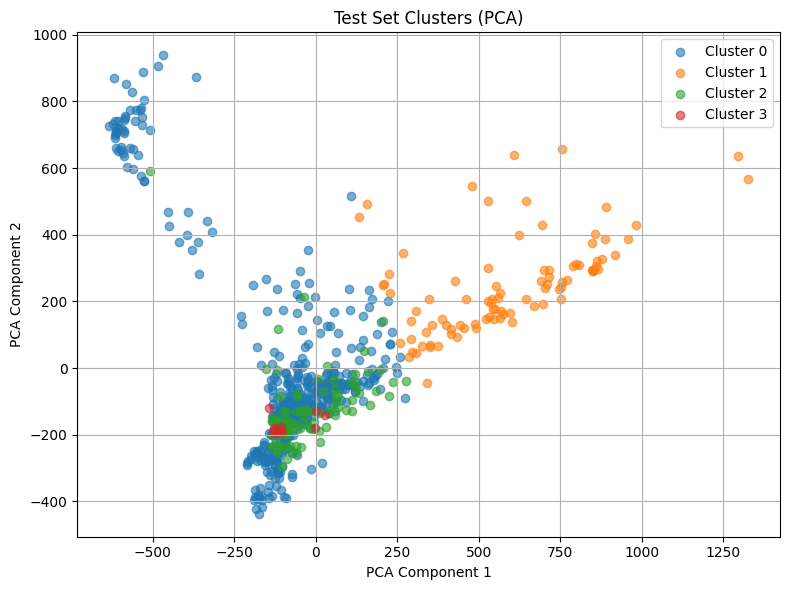

In [14]:

import pickle
import os

Test_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset"
Test_clusters = {}

# Load clusters from pickle files
for i in range(4):  
    path = os.path.join(Test_dir, f"cluster_{i}.pkl")
    with open(path, "rb") as f:
        Test_clusters[i] = pickle.load(f)

# Print the size and shape of each cluster
for cluster_id, data in Test_clusters.items():
    print(f"Cluster {cluster_id}: size = {len(data)}, shape = {data.shape}")


plot_clusters_pca(test_X, test_clusters, title="Test Set Clusters (PCA)")


Epoch 1/100 - Loss: 0.092202
Epoch 2/100 - Loss: 0.034951
Epoch 3/100 - Loss: 0.031328
Epoch 4/100 - Loss: 0.030853
Epoch 5/100 - Loss: 0.029379
Epoch 6/100 - Loss: 0.027977
Epoch 7/100 - Loss: 0.026868
Epoch 8/100 - Loss: 0.025779
Epoch 9/100 - Loss: 0.024650
Epoch 10/100 - Loss: 0.023615
Epoch 11/100 - Loss: 0.022480
Epoch 12/100 - Loss: 0.021735
Epoch 13/100 - Loss: 0.020775
Epoch 14/100 - Loss: 0.020245
Epoch 15/100 - Loss: 0.019066
Epoch 16/100 - Loss: 0.018188
Epoch 17/100 - Loss: 0.017554
Epoch 18/100 - Loss: 0.016792
Epoch 19/100 - Loss: 0.014073
Epoch 20/100 - Loss: 0.015427
Epoch 21/100 - Loss: 0.014814
Epoch 22/100 - Loss: 0.014753
Epoch 23/100 - Loss: 0.013786
Epoch 24/100 - Loss: 0.013270
Epoch 25/100 - Loss: 0.013067
Epoch 26/100 - Loss: 0.012329
Epoch 27/100 - Loss: 0.011970
Epoch 28/100 - Loss: 0.011548
Epoch 29/100 - Loss: 0.011269
Epoch 30/100 - Loss: 0.011521
Epoch 31/100 - Loss: 0.010706
Epoch 32/100 - Loss: 0.010376
Epoch 33/100 - Loss: 0.010411
Epoch 34/100 - Loss

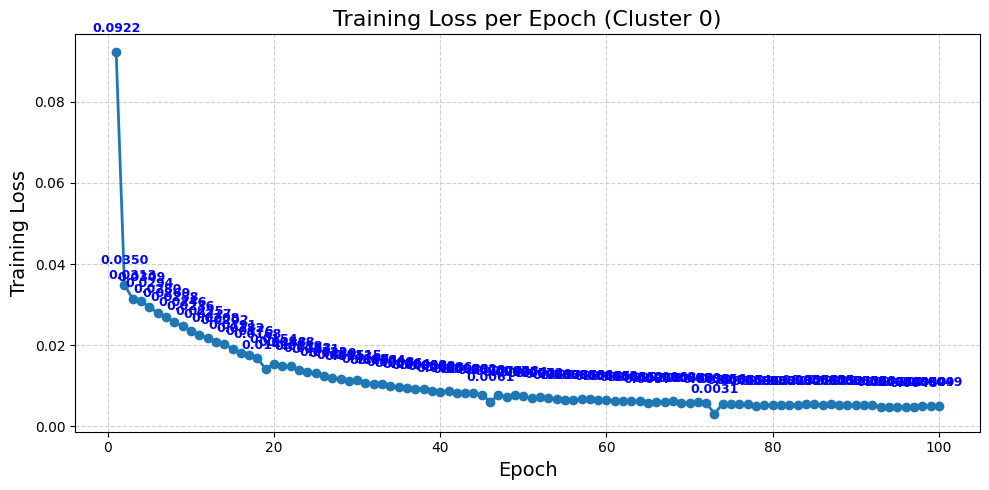

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\models_\model0000


In [9]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 0 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0.pkl", "rb") as f:
    X_cluster0 = pickle.load(f)

cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_0_indices.npy")
y_cluster0 = train_dataset.y[cluster_0_indices]

# Ensure y is 2D
if len(y_cluster0.shape) == 1:
    y_cluster0 = y_cluster0.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_0 = dc.data.NumpyDataset(X=np.array(X_cluster0), y=np.array(y_cluster0))

# === Model config
n_tasks = train_dataset_0.y.shape[1]
n_features = train_dataset_0.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_0 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\models_\model0000"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_0.fit(train_dataset_0, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 0)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_0.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [10]:
import pickle
import numpy as np

# === Load cluster 0 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0.pkl", "rb") as f:
    X_test_cluster0 = pickle.load(f)

# === Load corresponding indices
test_cluster_0_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_0_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster0 = test_dataset.y[test_cluster_0_indices]

if len(y_test_cluster0.shape) == 1:
    y_test_cluster0 = y_test_cluster0.reshape(-1, 1)


In [11]:

import deepchem as dc
test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

test_dataset_0 = dc.data.NumpyDataset(X=np.array(X_test_cluster0), y=np.array(y_test_cluster0))

predictions_0 = model_0.predict(test_dataset_0)

print("✅ Prediction shape:", predictions_0.shape)
print("Example prediction:", predictions_0[0])



✅ Prediction shape: (483, 3726, 2)
Example prediction: [[1.0000000e+00 2.9883913e-13]
 [1.0000000e+00 1.4600357e-13]
 [1.0000000e+00 3.0751966e-12]
 ...
 [1.0000000e+00 7.9019731e-14]
 [1.0000000e+00 9.0660574e-13]
 [4.2102579e-13 1.0000000e+00]]


In [12]:
itos={}
c=0
for i in symbol_to_idx:
  itos[c]=i
  c=c+1
itos
from rdkit import Chem, DataStructs
import numpy as np


In [13]:

def evaluate_flat_predictions(predictions, test_dataset, itos, sf, cutoff=0.5):
    """
    Evaluate SELFIES predictions from flat one-hot output format.
    Args:
        predictions: model outputs (shape: [num_samples, sequence_len * vocab_size])
        test_dataset: DeepChem test dataset
        itos: index-to-symbol mapping (dict or list)
        sf: selfies module (with decoder)
        cutoff: threshold for class activation

    Returns:
        Prints evaluation stats and decoded examples
    """
    if isinstance(itos, list):
        itos = {i: tok for i, tok in enumerate(itos)}

    vocab_size = len(itos)
    total = len(test_dataset)
    hit = 0
    tanimoto_scores = []

    for idx in range(total):
        flat_pred = predictions[idx]
        binary_pred = [1 if val[1] >= cutoff else 0 for val in flat_pred]  

        num_tokens = len(binary_pred) // vocab_size
        selfie_str = ''
        for i in range(num_tokens):
            for j in range(vocab_size):
                if binary_pred[i * vocab_size + j] == 1 and itos[j] != '[nop]':
                    selfie_str += itos[j]

        try:
            pred_smiles = sf.decoder(selfie_str)
        except:
            pred_smiles = ''

        ground_truth_flat = test_dataset.y[idx]
        true_indices = np.argmax(ground_truth_flat.reshape(-1, vocab_size), axis=1)
        true_selfie = ''.join([itos.get(i, '') for i in true_indices])
        try:
            true_smiles = sf.decoder(true_selfie)
        except:
            true_smiles = ''

        # RDKit comparison
        mol_pred = Chem.MolFromSmiles(pred_smiles)
        mol_true = Chem.MolFromSmiles(true_smiles)
        if mol_pred is None or mol_true is None:
            tanimoto = 0.0
        else:
            fp_pred = Chem.RDKFingerprint(mol_pred)
            fp_true = Chem.RDKFingerprint(mol_true)
            tanimoto = DataStructs.FingerprintSimilarity(fp_pred, fp_true)

        tanimoto_scores.append(tanimoto)
        if pred_smiles == true_smiles:
            hit += 1

        print(f"[{idx}] Pred: {pred_smiles} | True: {true_smiles} | Tanimoto: {tanimoto:.3f}")

    # Summary
    tanimoto_scores = np.array(tanimoto_scores)
    print("\n📊 Evaluation Summary:")
    print(f"✅ Exact SMILES match: {hit}/{total} ({100*hit/total:.1f}%)")
    print(f"Tanimoto >= 1.0: {np.sum(tanimoto_scores == 1.0)}")
    print(f"Tanimoto >= 0.9: {np.sum(tanimoto_scores >= 0.9)}")
    print(f"Tanimoto >= 0.6: {np.sum(tanimoto_scores >= 0.6)}")
    print(f"Avg Tanimoto: {tanimoto_scores.mean():.3f}")


In [14]:
evaluate_flat_predictions(predictions_0, test_dataset_0, itos, sf, cutoff=0.5)


[0] Pred: [O-1][N+1](=O)C1=C(F)C=C(F)C=C1F | True: [O-1][N+1](=O)C1=C(F)C=C(F)C=C1F | Tanimoto: 1.000
[1] Pred: COCCOC1=NC=C(NC(=O)OCC#C)C=C1C(F)(F)F | True: COCCOC1=NC=C(NC(=O)OCC#C)C=C1C(F)(F)F | Tanimoto: 1.000
[2] Pred: CC1=CC(=O)N2N=C(N=C2N1)C(F)(F)F | True: CC1=CC(=O)N2N=C(N=C2N1)C(F)(F)F | Tanimoto: 1.000
[3] Pred: COC1=NC=C(C=C1NC(=O)OCC#C)C(F)(F)F | True: COC1=NC=C(C=C1NC(=O)OCC#C)C(F)(F)F | Tanimoto: 1.000
[4] Pred: FC1=CC=C(OC2=CC(=NC3=C(C=CC=C23)C#N)C(F)(F)F)C=C1 | True: FC1=CC=C(OC2=CC(=NC3=C(C=CC=C23)C#N)C(F)(F)F)C=C1 | Tanimoto: 1.000
[5] Pred: CC12N=NCC1C(=O)N(C2=O)C3=CC=CC=C3F | True: CC12N=NCC1C(=O)N(C3=CC=C(F)C=C3)C2=O | Tanimoto: 0.913
[6] Pred: CCCCCNC=C=CF | True: CCOC(C)N1C=C(F)C(=O)NC1=O | Tanimoto: 0.041
[7] Pred: C(C)(C)CC=O | True: NC(=O)C1=C(F)C(=O)NC(=O)N1 | Tanimoto: 0.013
[8] Pred: C1C=CC=C1CC=O | True: FC(F)(F)C1=CC(=O)NC(=O)N1 | Tanimoto: 0.033
[9] Pred: NC(=O)NN=CC1=C(F)C=CC=C1F | True: NC(=O)NN=CC1=CC(F)=CC(F)=C1 | Tanimoto: 0.657
[10] Pred: CN(C)CCOC

Epoch 1/100 - Loss: 0.326326
Epoch 2/100 - Loss: 0.037727
Epoch 3/100 - Loss: 0.034016
Epoch 4/100 - Loss: 0.032044
Epoch 5/100 - Loss: 0.030617
Epoch 6/100 - Loss: 0.029057
Epoch 7/100 - Loss: 0.027371
Epoch 8/100 - Loss: 0.025721
Epoch 9/100 - Loss: 0.023984
Epoch 10/100 - Loss: 0.022477
Epoch 11/100 - Loss: 0.021013
Epoch 12/100 - Loss: 0.019637
Epoch 13/100 - Loss: 0.014912
Epoch 14/100 - Loss: 0.016873
Epoch 15/100 - Loss: 0.015506
Epoch 16/100 - Loss: 0.014392
Epoch 17/100 - Loss: 0.013441
Epoch 18/100 - Loss: 0.012193
Epoch 19/100 - Loss: 0.011336
Epoch 20/100 - Loss: 0.010546
Epoch 21/100 - Loss: 0.009673
Epoch 22/100 - Loss: 0.008871
Epoch 23/100 - Loss: 0.008254
Epoch 24/100 - Loss: 0.007549
Epoch 25/100 - Loss: 0.007026
Epoch 26/100 - Loss: 0.006433
Epoch 27/100 - Loss: 0.006114
Epoch 28/100 - Loss: 0.005627
Epoch 29/100 - Loss: 0.005328
Epoch 30/100 - Loss: 0.004948
Epoch 31/100 - Loss: 0.004422
Epoch 32/100 - Loss: 0.004233
Epoch 33/100 - Loss: 0.004106
Epoch 34/100 - Loss

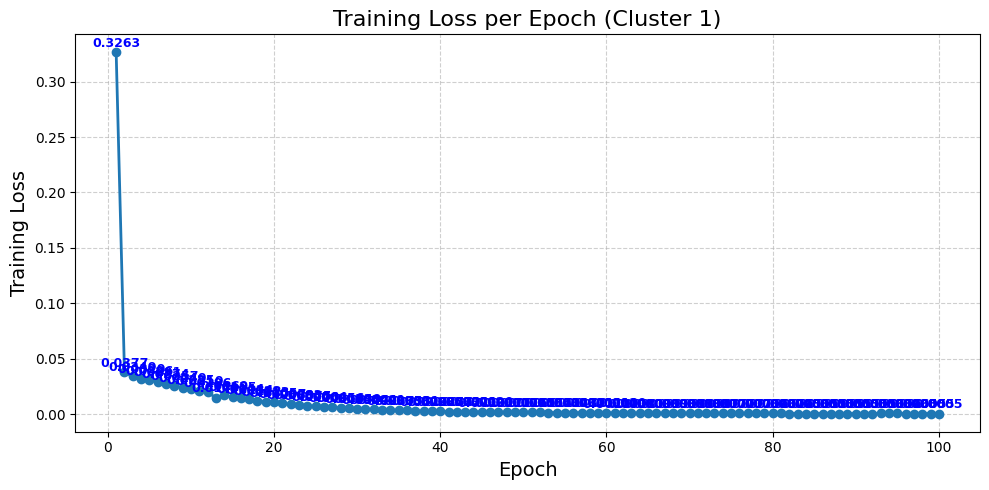

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with seed 123\models_\model1111


In [15]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 1 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_1.pkl", "rb") as f:
    X_cluster1 = pickle.load(f)

cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_1_indices.npy")
y_cluster1 = train_dataset.y[cluster_1_indices]

# Ensure y is 2D
if len(y_cluster1.shape) == 1:
    y_cluster1 = y_cluster1.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_1 = dc.data.NumpyDataset(X=np.array(X_cluster1), y=np.array(y_cluster1))

# === Model config
n_tasks = train_dataset_1.y.shape[1]
n_features = train_dataset_1.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_1 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with seed 123\models_\model1111"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_1.fit(train_dataset_1, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 1)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_1.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)



In [16]:
import pickle
import numpy as np
import deepchem as dc

# === Load cluster 1 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1.pkl", "rb") as f:
    X_test_cluster1 = pickle.load(f)

# === Load corresponding indices
test_cluster_1_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_1_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster1 = test_dataset.y[test_cluster_1_indices]

if len(y_test_cluster1.shape) == 1:
    y_test_cluster1 = y_test_cluster1.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 1
test_dataset_1 = dc.data.NumpyDataset(X=np.array(X_test_cluster1), y=np.array(y_test_cluster1))

# === Predict using the trained model_1
predictions_1 = model_1.predict(test_dataset_1)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_1.shape)
print("Example prediction:", predictions_1[0])
evaluate_flat_predictions(predictions_1, test_dataset_1, itos, sf, cutoff=0.5)


✅ Prediction shape: (91, 3726, 2)
Example prediction: [[1.0000000e+00 5.4781224e-10]
 [1.0000000e+00 1.1475462e-09]
 [1.0000000e+00 1.1345149e-08]
 ...
 [1.0000000e+00 9.1952912e-10]
 [1.0000000e+00 5.0863569e-08]
 [1.6661815e-07 9.9999988e-01]]
[0] Pred: CCCC(=O)NC(NC1=CC=C(F)C(F)=C1)(C(=O)OCC)C(F)(F)F | True: CCCC(=O)NC(NC1=CC=C(F)C(F)=C1)(C(=O)OCC)C(F)(F)F | Tanimoto: 1.000
[1] Pred: CCCC(=O)NC(NC1=CC=CC=C1C(F)(F)F)(C(F)(F)F)C(F)(F)F | True: CCCC(=O)NC(NC1=CC=CC=C1C(F)(F)F)(C(F)(F)F)C(F)(F)F | Tanimoto: 1.000
[2] Pred: CCCC(=O)NC(NC1=CC=CC(=C1)C(F)(F)F)(C(=O)OCC)C(F)(F)F | True: CCCC(=O)NC(NC1=CC=CC(=C1)C(F)(F)F)(C(=O)OCC)C(F)(F)F | Tanimoto: 1.000
[3] Pred: CCCCCCCCCCCCOC(=O)C(=O)NC1=CC=CC=C1F | True: CCCCCCCCCCCCOC(=O)C(=O)NC1=CC=CC=C1F | Tanimoto: 1.000
[4] Pred: CC(C)NC1=NC(NC2=CC=C(C=C2)C(C)=O)=NC(OC(C(F)(F)F)C(F)(F)F)=N1 | True: CC(C)NC1=NC(NC2=CC=C(C=C2)C(C)=O)=NC(OC(C(F)(F)F)C(F)(F)F)=N1 | Tanimoto: 1.000
[5] Pred: NCCC1=C(F)[NH1]C2=CC(F)=C(O)C=C12 | True: NCCC1=C(F)[NH1]C2=

---------------------------------------------------

Epoch 1/100 - Loss: 0.287300
Epoch 2/100 - Loss: 0.042491
Epoch 3/100 - Loss: 0.038866
Epoch 4/100 - Loss: 0.037056
Epoch 5/100 - Loss: 0.035731
Epoch 6/100 - Loss: 0.034387
Epoch 7/100 - Loss: 0.033051
Epoch 8/100 - Loss: 0.031700
Epoch 9/100 - Loss: 0.030424
Epoch 10/100 - Loss: 0.029133
Epoch 11/100 - Loss: 0.027756
Epoch 12/100 - Loss: 0.026293
Epoch 13/100 - Loss: 0.025198
Epoch 14/100 - Loss: 0.023946
Epoch 15/100 - Loss: 0.022726
Epoch 16/100 - Loss: 0.021507
Epoch 17/100 - Loss: 0.020347
Epoch 18/100 - Loss: 0.019075
Epoch 19/100 - Loss: 0.018034
Epoch 20/100 - Loss: 0.016935
Epoch 21/100 - Loss: 0.015974
Epoch 22/100 - Loss: 0.015005
Epoch 23/100 - Loss: 0.013962
Epoch 24/100 - Loss: 0.013334
Epoch 25/100 - Loss: 0.012473
Epoch 26/100 - Loss: 0.011851
Epoch 27/100 - Loss: 0.011171
Epoch 28/100 - Loss: 0.010492
Epoch 29/100 - Loss: 0.010065
Epoch 30/100 - Loss: 0.009438
Epoch 31/100 - Loss: 0.008788
Epoch 32/100 - Loss: 0.008597
Epoch 33/100 - Loss: 0.007993
Epoch 34/100 - Loss

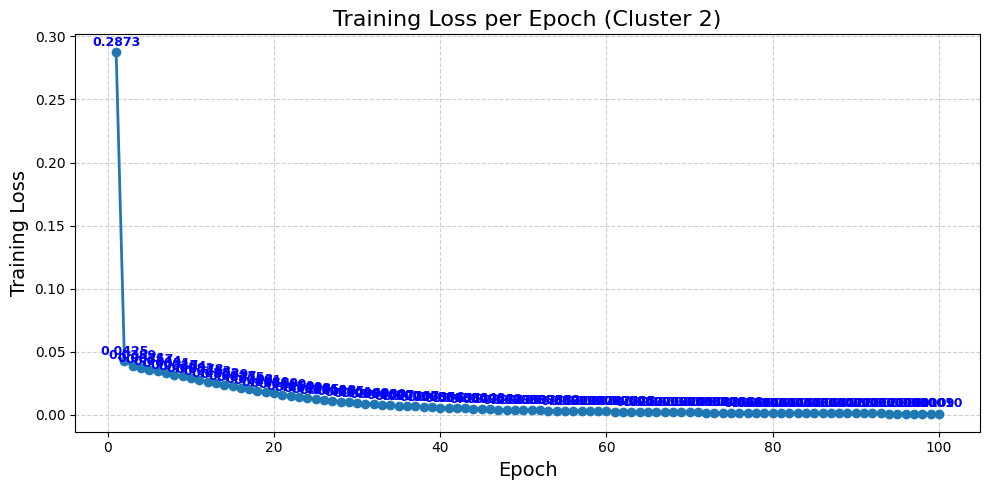

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with seed 123\models_\model2222


In [17]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 2 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_2.pkl", "rb") as f:
    X_cluster2 = pickle.load(f)

cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_2_indices.npy")
y_cluster2 = train_dataset.y[cluster_2_indices]

if len(y_cluster2.shape) == 1:
    y_cluster2 = y_cluster2.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_2 = dc.data.NumpyDataset(X=np.array(X_cluster2), y=np.array(y_cluster2))

# === Model config
n_tasks = train_dataset_2.y.shape[1]
n_features = train_dataset_2.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_2 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with seed 123\models_\model2222"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_2.fit(train_dataset_2, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 2)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_2.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [18]:
# === Load cluster 2 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2.pkl", "rb") as f:
    X_test_cluster2 = pickle.load(f)

# === Load corresponding indices
test_cluster_2_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_2_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster2 = test_dataset.y[test_cluster_2_indices]

if len(y_test_cluster2.shape) == 1:
    y_test_cluster2 = y_test_cluster2.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 2
test_dataset_2 = dc.data.NumpyDataset(X=np.array(X_test_cluster2), y=np.array(y_test_cluster2))

# === Predict using the trained model_2
predictions_2 = model_2.predict(test_dataset_2)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_2.shape)
print("Example prediction:", predictions_2[0])

evaluate_flat_predictions(predictions_2, test_dataset_2, itos, sf, cutoff=0.5)


✅ Prediction shape: (93, 3726, 2)
Example prediction: [[9.9999988e-01 1.2536019e-07]
 [9.9999988e-01 1.3483243e-07]
 [1.0000000e+00 2.2592625e-08]
 ...
 [9.9999988e-01 9.3507275e-08]
 [9.9999976e-01 1.8004344e-07]
 [1.9582299e-07 9.9999976e-01]]
[0] Pred: FC(F)(F)C=CC=CC=CC | True: [O-1][N+1](=O)C1=CC(=CC=C1OC2=CC=CN=C2)C(F)(F)F | Tanimoto: 0.030
[1] Pred: NC(=O)C1=CC=C(C=C1)N2N=NN=C2OC3=CC=C(F)C=C3 | True: NC(=O)C1=CC=C(C=C1)N2N=NN=C2OC3=CC=C(F)C=C3 | Tanimoto: 1.000
[2] Pred: FC(F)(F)C(=O)NC1=NC(=O)C=2N=CN(C3CC(OC(=O)C(F)(F)F)C(COC(=O)C(F)(F)F)O3)C=2N1 | True: FC(F)(F)C(=O)NC1=NC(=O)C=2N=CN(C3CC(OC(=O)C(F)(F)F)C(COC(=O)C(F)(F)F)O3)C=2N1 | Tanimoto: 1.000
[3] Pred: CCC=O | True: [O-1][N+1](=O)C1=CC(=CC=C1NC(=O)C(F)(F)F)N=NC2=CC=CC=C2 | Tanimoto: 0.011
[4] Pred: OC1(CC(=NN1C(=O)C2=CC=CC=N2)C(F)(F)F)C3=CC=CN=C3 | True: OC1(CC(=NN1C(=O)C2=CC=CC=N2)C(F)(F)F)C3=CC=CN=C3 | Tanimoto: 1.000
[5] Pred: FCC1CN(C(=O)O1)C2=CC=CC=C2 | True: FCC1CN(C(=O)O1)C2=CC=CC=C2 | Tanimoto: 1.000
[6] Pred: [O-

Epoch 1/100 - Loss: 0.795116
Epoch 2/100 - Loss: 0.053050
Epoch 3/100 - Loss: 0.047536
Epoch 4/100 - Loss: 0.039800
Epoch 5/100 - Loss: 0.028413
Epoch 6/100 - Loss: 0.023035
Epoch 7/100 - Loss: 0.021183
Epoch 8/100 - Loss: 0.020562
Epoch 9/100 - Loss: 0.019804
Epoch 10/100 - Loss: 0.019141
Epoch 11/100 - Loss: 0.018426
Epoch 12/100 - Loss: 0.017970
Epoch 13/100 - Loss: 0.017240
Epoch 14/100 - Loss: 0.016764
Epoch 15/100 - Loss: 0.016078
Epoch 16/100 - Loss: 0.015525
Epoch 17/100 - Loss: 0.015000
Epoch 18/100 - Loss: 0.014728
Epoch 19/100 - Loss: 0.014176
Epoch 20/100 - Loss: 0.013770
Epoch 21/100 - Loss: 0.013336
Epoch 22/100 - Loss: 0.012967
Epoch 23/100 - Loss: 0.012568
Epoch 24/100 - Loss: 0.012113
Epoch 25/100 - Loss: 0.011591
Epoch 26/100 - Loss: 0.011400
Epoch 27/100 - Loss: 0.011044
Epoch 28/100 - Loss: 0.010583
Epoch 29/100 - Loss: 0.010628
Epoch 30/100 - Loss: 0.010052
Epoch 31/100 - Loss: 0.009976
Epoch 32/100 - Loss: 0.009662
Epoch 33/100 - Loss: 0.009563
Epoch 34/100 - Loss

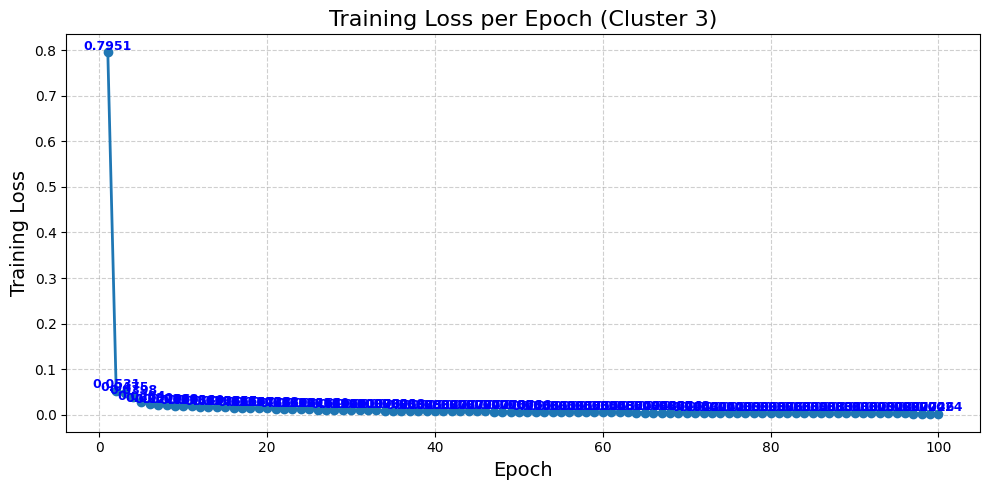

✅ Training complete. Model, loss plot, and architecture saved to:
C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with seed 123\models_\model3333


In [19]:
import os
import json
import pickle
import numpy as np
import matplotlib.pyplot as plt
import deepchem as dc

# === Load training cluster 3 data
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_3.pkl", "rb") as f:
    X_cluster3 = pickle.load(f)

cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  seed 123\clustering_from_trainset\cluster_3_indices.npy")
y_cluster3 = train_dataset.y[cluster_3_indices]

if len(y_cluster3.shape) == 1:
    y_cluster3 = y_cluster3.reshape(-1, 1)

# === Create DeepChem dataset
train_dataset_3 = dc.data.NumpyDataset(X=np.array(X_cluster3), y=np.array(y_cluster3))

# === Model config
n_tasks = train_dataset_3.y.shape[1]
n_features = train_dataset_3.X.shape[1]
layer_sizes = [1000, 1000, 1000]
dropout_rate = 0.1
num_epochs = 100

model_3 = dc.models.MultitaskClassifier(
    n_tasks=n_tasks,
    n_features=n_features,
    layer_sizes=layer_sizes,
    dropouts=dropout_rate
)

# === Output directory
model_dir = r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with seed 123\models_\model3333"
os.makedirs(model_dir, exist_ok=True)

# === Training
losses = []

for epoch in range(num_epochs):
    loss = model_3.fit(train_dataset_3, nb_epoch=1)
    losses.append(loss)
    print(f"Epoch {epoch + 1}/{num_epochs} - Loss: {loss:.6f}")

# === Plot training loss
final_plot = os.path.join(model_dir, "train_loss_plot.png")
plt.figure(figsize=(10, 5))
plt.plot(range(1, len(losses) + 1), losses, marker='o', linewidth=2, markersize=6)
for i, l in enumerate(losses):
    plt.text(i + 1, l + 0.005, f"{l:.4f}", fontsize=9, fontweight='bold', ha='center', color='blue')

plt.title("Training Loss per Epoch (Cluster 3)", fontsize=16)
plt.xlabel("Epoch", fontsize=14)
plt.ylabel("Training Loss", fontsize=14)
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(final_plot)
plt.show()

# === Save model weights and architecture
model_3.save_checkpoint(model_dir=model_dir)

arch_dict = {
    "n_tasks": n_tasks,
    "n_features": n_features,
    "layer_sizes": layer_sizes,
    "dropout_rate": dropout_rate
}
arch_file = os.path.join(model_dir, "architecture.json")
with open(arch_file, "w") as f:
    json.dump(arch_dict, f, indent=4)

print("✅ Training complete. Model, loss plot, and architecture saved to:")
print(model_dir)


In [20]:
# === Load cluster 3 features from test set
with open(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3.pkl", "rb") as f:
    X_test_cluster3 = pickle.load(f)

# === Load corresponding indices
test_cluster_3_indices = np.load(r"C:\Users\EI48583\OneDrive - Envalior\Desktop\new version\splitting  method with high results\Codes  with new data sets\_aromatic_2025_6022_CFHNO\Splitting  with  Splitting  with seed 123\clustering_from_testset\cluster_3_indices.npy")

# === Extract corresponding labels from the original test set
y_test_cluster3 = test_dataset.y[test_cluster_3_indices]

if len(y_test_cluster3.shape) == 1:
    y_test_cluster3 = y_test_cluster3.reshape(-1, 1)

# === Create DeepChem dataset for test cluster 3
test_dataset_3 = dc.data.NumpyDataset(X=np.array(X_test_cluster3), y=np.array(y_test_cluster3))

# === Predict using the trained model_3
predictions_3 = model_3.predict(test_dataset_3)

# === Inspect prediction shape 
print("✅ Prediction shape:", predictions_3.shape)
print("Example prediction:", predictions_3[0])

evaluate_flat_predictions(predictions_3, test_dataset_3, itos, sf, cutoff=0.5)


✅ Prediction shape: (12, 3726, 2)
Example prediction: [[9.9999976e-01 2.8389823e-07]
 [9.9999905e-01 9.4231285e-07]
 [9.9999988e-01 1.2536617e-07]
 ...
 [9.9999988e-01 1.0234411e-07]
 [9.9999976e-01 2.7592907e-07]
 [2.0107004e-06 9.9999797e-01]]
[0] Pred: FC(F)(F)C=CC=C=C | True: CC(=O)NC1=NON=C1C2=NC3=CC=CC=C3N2CC4=CC=CC(=C4)C(F)(F)F | Tanimoto: 0.029
[1] Pred: CCF | True: [O-1][N+1](=O)C=NNC1=CC=CC=C1C2=NOC(=N2)C(F)(F)F | Tanimoto: 0.005
[2] Pred: FC=CC=C(C)CC | True: CCC1=CC=CC=C1NC(=O)C2=CC=C(F)C(F)=C2F | Tanimoto: 0.022
[3] Pred: FC=CC=CCC=CC(C)CC=C=CF | True: COC(=O)[C@H1](CC1=CC=CC=C1)NC(=O)C2=CC=C(F)C(F)=C2F | Tanimoto: 0.050
[4] Pred: CCCC(C(=O)CCC=CC=C)(C)CCF | True: COC(=O)[C@@H1]1CCCN1C(=O)C2=CC=C(F)C(F)=C2F | Tanimoto: 0.098
[5] Pred: CCCCCCCCCCCCCCOCC=O | True: CCCCCCCCCCCCCCCOC(=O)CNC(=O)C1=CC=C(F)C(F)=C1F | Tanimoto: 0.110
[6] Pred: CC1=CC=CC(NC(=O)C2=CC=C(F)C(F)=C2F)=C1 | True: CN(C1=CC=CC=C1)C(=O)C2=CC=C(F)C(F)=C2F | Tanimoto: 0.754
[7] Pred: CCCCCCCCCCCCCCC=CC#C | Tr